# Regressão Linear com NumPy

## Objetivos deste experimento

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se programação totalmente NumPy com:
- o **cálculo do gradiente**,
- a **função de perda** e
- a atualização dos parâmetros são feitos de forma explícita.
- A rede é criada com uma camada como uma classe

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt   # para plotting

from sklearn.datasets import load_iris  # para carregar dataset

import numpy as np  # processamento matricial

np.random.seed(1234)

## Dataset

### Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1]
y_train = data[:,1:2]

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float64
y_train.shape: (50, 1) float64
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

Text(0, 0.5, 'Comprimento petalas')

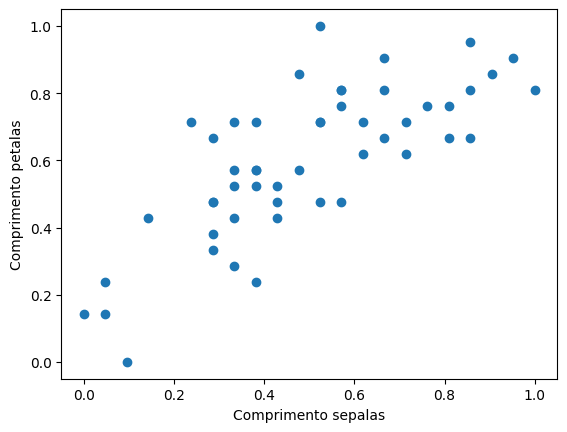

In [4]:
plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

## Modelo da rede

### Reta de ajuste

A equação da reta no plano necessita de dois parâmetros, aqui denominados $w_0$ (*bias*) e inclinação $w_1$. Veja figura:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/linhareta.png)

A reta de ajuste será dada por:

$$ \hat{y} = w_0 + w_1 x $$

onde
* $w_1$ é o coeficiente angular da reta e
* $w_0$ é a interseção do eixo vertical quando x é igual a zero, também denominado de *bias*.
* $x$ é a variável de entrada (comprimento das sépalas) e
* $\hat{y}$ é a predição (comprimento estimado das pétalas).

### Linear Regression Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

### Formulação matricial do neurônio

* $\mathbf{w} = [w_0 \ w_1]$ é vetor linha de parâmetros e
* $\mathbf{x} = [1 \ x_0] $ é vetor linha de uma amostra (com *bias*).

$$ \hat{y} = 1 w_0 + x_0 w_1 $$

$$ [\hat{y}] = [1 \ x_0] \begin{bmatrix} w_0 \\ w_1 \end{bmatrix} $$

$$ \mathbf{\hat{y}} = \mathbf{x} \mathbf{w^T} $$

### Fazendo o predict de várias amostras

$$ \begin{matrix}
\begin{bmatrix}
\hat{y}_0\\
\hat{y}_1\\
\\
\hat{y}_{M-1}
\end{bmatrix} &=& \begin{bmatrix}
1 & x_0 \\
1 & x_1\\
\\
1 & x_{M-1} \\
\end{bmatrix}
&
\begin{bmatrix}
w_0\\
w_1
\end{bmatrix} \\
(M,1) & & (M,2) & (2,1) \\
\end{matrix} $$

### Preenchendo x com coluna de 1's para bias

In [5]:
x_train

array([[1.        ],
       [0.71428571],
       [0.95238095],
       [0.28571429],
       [0.76190476],
       [0.38095238],
       [0.66666667],
       [0.        ],
       [0.80952381],
       [0.14285714],
       [0.04761905],
       [0.47619048],
       [0.52380952],
       [0.57142857],
       [0.33333333],
       [0.85714286],
       [0.33333333],
       [0.42857143],
       [0.61904762],
       [0.33333333],
       [0.47619048],
       [0.57142857],
       [0.66666667],
       [0.57142857],
       [0.71428571],
       [0.80952381],
       [0.9047619 ],
       [0.85714286],
       [0.52380952],
       [0.38095238],
       [0.28571429],
       [0.28571429],
       [0.42857143],
       [0.52380952],
       [0.23809524],
       [0.52380952],
       [0.85714286],
       [0.66666667],
       [0.33333333],
       [0.28571429],
       [0.28571429],
       [0.57142857],
       [0.42857143],
       [0.04761905],
       [0.33333333],
       [0.38095238],
       [0.38095238],
       [0.619

In [7]:
np.ones ( shape=(n_samples,1) )

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [8]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [9]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428571],
       [1.        , 0.95238095],
       [1.        , 0.28571429],
       [1.        , 0.76190476],
       [1.        , 0.38095238],
       [1.        , 0.66666667],
       [1.        , 0.        ],
       [1.        , 0.80952381],
       [1.        , 0.14285714],
       [1.        , 0.04761905],
       [1.        , 0.47619048],
       [1.        , 0.52380952],
       [1.        , 0.57142857],
       [1.        , 0.33333333],
       [1.        , 0.85714286],
       [1.        , 0.33333333],
       [1.        , 0.42857143],
       [1.        , 0.61904762],
       [1.        , 0.33333333],
       [1.        , 0.47619048],
       [1.        , 0.57142857],
       [1.        , 0.66666667],
       [1.        , 0.57142857],
       [1.        , 0.71428571],
       [1.        , 0.80952381],
       [1.        , 0.9047619 ],
       [1.        , 0.85714286],
       [1.        , 0.52380952],
       [1.        , 0.38095238],
       [1.

### Classe com o modelo da rede

In [14]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = np.random.uniform(-0.1,0.1,(n_out,n_in)) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.dot(self.w.T)

### Criando a rede, instanciando o objeto model

In [15]:
model = Net(2,1) # duas entradas (1 + x0) e uma saída y_pred

In [16]:
model.w

array([[-0.01245445,  0.05707172]])

### Testando o predict da rede (mesmo sem treiná-la)

In [17]:
xin = np.random.randn(4,2) # 4 amostras, 2 entradas (1 + x0)
ypred = model.forward(xin)
ypred

array([[ 0.05960645],
       [-0.04703319],
       [-0.12818937],
       [ 0.042289  ]])

In [18]:
ypred = model.forward(x_train_bias)

## Treinamento via gradiente descendente

Função de perda:
$$ J(\hat{y_i},y_i) = \frac{1}{M} \sum_{i=0}^{M-1} (\hat{y_i} - y_i)^2 $$

Gradiente:
$$  \mathbf{\nabla{J_w}} = \frac{2}{M}\mathbf{x^T}(\mathbf{x w^T} - \mathbf{y}) $$

Atualização dos parâmetros pelo gradiente descendente:
$$ \mathbf{w} = \mathbf{w} − \eta (\mathbf{\nabla J_w})^T $$

### Laço de treinamento

In [29]:
num_epochs = 100
learning_rate = 0.5
for epoch in range(num_epochs):

    # forward - predict
    y_pred = model.forward(x_train_bias)

    #loss cálculo da função de perda
    loss = np.square(y_pred - y_train).mean()

    # cálculo do gradiente pelas derivadas parciais
    w_grad = (2.0/n_samples) * (x_train_bias.T).dot(x_train_bias.dot(model.w.T) - y_train)

    # gradiente descendente
    model.w = model.w - learning_rate * w_grad.T

    # verbose
    if (epoch+1) % 1 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss))

Epoch[1/100], loss: 0.021170
Epoch[2/100], loss: 0.021170
Epoch[3/100], loss: 0.021170
Epoch[4/100], loss: 0.021170
Epoch[5/100], loss: 0.021170
Epoch[6/100], loss: 0.021170
Epoch[7/100], loss: 0.021170
Epoch[8/100], loss: 0.021170
Epoch[9/100], loss: 0.021170
Epoch[10/100], loss: 0.021170
Epoch[11/100], loss: 0.021170
Epoch[12/100], loss: 0.021170
Epoch[13/100], loss: 0.021170
Epoch[14/100], loss: 0.021170
Epoch[15/100], loss: 0.021170
Epoch[16/100], loss: 0.021170
Epoch[17/100], loss: 0.021170
Epoch[18/100], loss: 0.021170
Epoch[19/100], loss: 0.021170
Epoch[20/100], loss: 0.021170
Epoch[21/100], loss: 0.021170
Epoch[22/100], loss: 0.021170
Epoch[23/100], loss: 0.021169
Epoch[24/100], loss: 0.021169
Epoch[25/100], loss: 0.021169
Epoch[26/100], loss: 0.021169
Epoch[27/100], loss: 0.021169
Epoch[28/100], loss: 0.021169
Epoch[29/100], loss: 0.021169
Epoch[30/100], loss: 0.021169
Epoch[31/100], loss: 0.021169
Epoch[32/100], loss: 0.021169
Epoch[33/100], loss: 0.021169
Epoch[34/100], loss

## Avaliação

### Predict

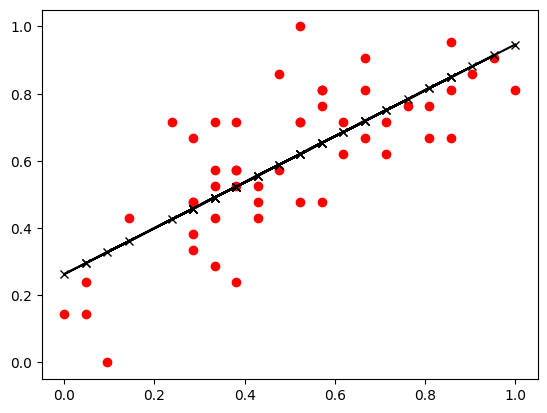

In [20]:
y_pred = model.forward(x_train_bias)
plt.plot(x_train, y_train, 'ro', label='Original data')
plt.plot(x_train, y_pred, 'kx-', label='Fitting Line')

### Parâmetros treinados

In [21]:
print(model.w)

[[0.26293022 0.68340143]]


### Avaliação do modelo

In [22]:
loss = np.square(y_pred - y_train).mean()
loss

np.float64(0.02116998714788002)

### Valor ótimo, solução analítica

$$  \mathbf{w} =(\mathbf{x^T} \mathbf{x})^{−1}\mathbf{x^T} \mathbf{y} $$

In [23]:
x = x_train_bias
y = y_train
w_opt = (np.linalg.inv((x.T).dot(x)).dot(x.T)).dot(y)
print(w_opt.T)

[[0.26134159 0.68646976]]


# Exercícios

## Questões

**1. Quantos parâmetros são treinados nesse modelo?**

O modelo treina 2 parâmetros: w0 (bias) e w1 (peso da entrada).

**2. Qual é o número de atributos de entrada para a rede?**

A rede recebe 2 entradas: uma coluna de bias e uma coluna com o valor de x.

**3. Qual é o número de saídas da rede?**

A rede possui 1 saída: o valor previsto de y.

**4. Suponha que eu tenha agora 5 mil amostras para fazer a predição. Qual é o shape da matriz de entrada? Qual é o shape do matriz de saída?**

Para 5.000 amostras:

Matriz de entrada: (5000, 2)

Matriz de saída: (5000, 1)


## Atividades

1. Modifique o laço do treinamento via gradiente descendente para guardar em uma lista, o valor da perda no final
   de cada época. Após o treinamento, plote o valor da perda em função da época.
2. Calcule o valor da perda (MSE) da rede com os parâmetros inicializados, sem serem treinados.
3. Coloque os valores dos pesos da solução ótima analítica no modelo da rede e calcule o valor da perda (MSE) e
   compare com o valor da perda obtida pelo método da otimização via gradiente descendente.

In [28]:
#1

model = Net(2, 1)

num_epochs = 100
learning_rate = 0.5

perdas = []

for epoch in range(num_epochs):

    # Forward - predict
    y_pred = model.forward(x_train_bias)

    # Cálculo da função de perda
    loss = np.square(y_pred - y_train).mean()

    # Guardando a perda em uma lista
    perdas.append(loss)

    # Cálculo do gradiente
    w_grad = (2.0 / n_samples) * (x_train_bias.T).dot(
        x_train_bias.dot(model.w.T) - y_train
    )

    # Atualização dos pesos pelo gradiente descendente
    model.w = model.w - learning_rate * w_grad.T

    # Exibir perda por época
    print('Epoch[{}/{}], loss: {:.6f}'.format(epoch+1, num_epochs, loss))

Epoch[1/100], loss: 0.426235
Epoch[2/100], loss: 0.055879
Epoch[3/100], loss: 0.030954
Epoch[4/100], loss: 0.028635
Epoch[5/100], loss: 0.027855
Epoch[6/100], loss: 0.027233
Epoch[7/100], loss: 0.026674
Epoch[8/100], loss: 0.026167
Epoch[9/100], loss: 0.025707
Epoch[10/100], loss: 0.025289
Epoch[11/100], loss: 0.024910
Epoch[12/100], loss: 0.024565
Epoch[13/100], loss: 0.024253
Epoch[14/100], loss: 0.023969
Epoch[15/100], loss: 0.023711
Epoch[16/100], loss: 0.023477
Epoch[17/100], loss: 0.023264
Epoch[18/100], loss: 0.023071
Epoch[19/100], loss: 0.022896
Epoch[20/100], loss: 0.022737
Epoch[21/100], loss: 0.022593
Epoch[22/100], loss: 0.022462
Epoch[23/100], loss: 0.022343
Epoch[24/100], loss: 0.022235
Epoch[25/100], loss: 0.022136
Epoch[26/100], loss: 0.022047
Epoch[27/100], loss: 0.021967
Epoch[28/100], loss: 0.021893
Epoch[29/100], loss: 0.021826
Epoch[30/100], loss: 0.021766
Epoch[31/100], loss: 0.021711
Epoch[32/100], loss: 0.021661
Epoch[33/100], loss: 0.021616
Epoch[34/100], loss

In [30]:
perdas

[np.float64(0.42623474067847744),
 np.float64(0.05587914959044243),
 np.float64(0.030953827421059173),
 np.float64(0.028635097325326972),
 np.float64(0.027855036117608603),
 np.float64(0.0272332696084596),
 np.float64(0.026674406928920966),
 np.float64(0.02616738245366014),
 np.float64(0.0257070780075364),
 np.float64(0.025289168320602955),
 np.float64(0.02490974744941594),
 np.float64(0.024565270549313106),
 np.float64(0.024252519338593636),
 np.float64(0.02396857193920762),
 np.float64(0.0237107755730798),
 np.float64(0.02347672177814152),
 np.float64(0.0232642239072527),
 np.float64(0.02307129669945335),
 np.float64(0.022896137732666674),
 np.float64(0.022737110584574203),
 np.float64(0.022592729544343323),
 np.float64(0.022461645732376648),
 np.float64(0.022342634498406885),
 np.float64(0.022234583980204028),
 np.float64(0.022136484716004542),
 np.float64(0.022047420213616754),
 np.float64(0.021966558388094262),
 np.float64(0.02189314378798386),
 np.float64(0.02182649053752181),
 n

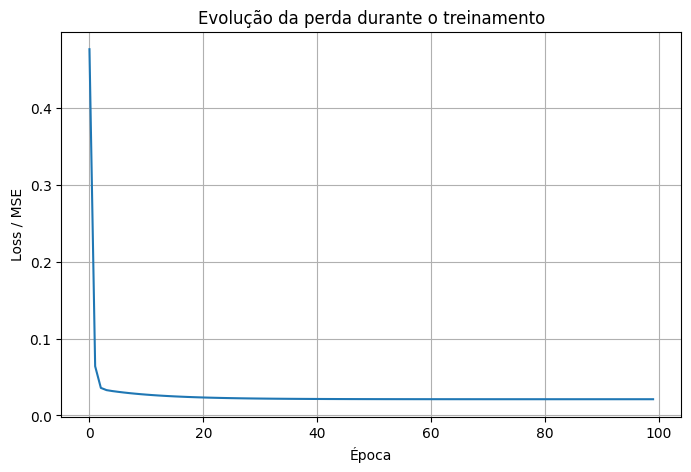

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Época')
plt.ylabel('Loss / MSE')
plt.title('Evolução da perda durante o treinamento')
plt.grid(True)
plt.show()

In [32]:
#2

# Criando um modelo novo, ainda sem treinamento
model_inicial = Net(2, 1)

# Fazendo predição com pesos aleatórios
y_pred_inicial = model_inicial.forward(x_train_bias)

# Calculando a perda inicial
loss_inicial = np.square(y_pred_inicial - y_train).mean()

print("MSE com pesos inicializados, sem treinamento:", loss_inicial)

MSE com pesos inicializados, sem treinamento: 0.5382612343347966


In [33]:
#3

x = x_train_bias
y = y_train

w_opt = np.linalg.inv(x.T.dot(x)).dot(x.T).dot(y)

print("Pesos ótimos pela solução analítica:")
print(w_opt.T)

Pesos ótimos pela solução analítica:
[[0.26134159 0.68646976]]


In [34]:
# Criando um novo modelo para receber os pesos ótimos
model_analitico = Net(2, 1)

# A classe Net armazena os pesos no shape (1, 2)
# w_opt está no shape (2, 1), por isso usamos transposta
model_analitico.w = w_opt.T

# Fazendo predição com os pesos ótimos
y_pred_analitico = model_analitico.forward(x_train_bias)

# Calculando o MSE com a solução analítica
loss_analitico = np.square(y_pred_analitico - y_train).mean()

print("MSE com solução analítica:", loss_analitico)

MSE com solução analítica: 0.021169424119097165


In [35]:
# Predição do modelo treinado por gradiente descendente
y_pred_gd = model.forward(x_train_bias)

# MSE do modelo treinado por gradiente descendente
loss_gd = np.square(y_pred_gd - y_train).mean()

print("MSE com gradiente descendente:", loss_gd)
print("MSE com solução analítica:", loss_analitico)

MSE com gradiente descendente: 0.021169424158935333
MSE com solução analítica: 0.021169424119097165


# Aprendizados

Nesta atividade, foi possível compreender como uma regressão linear simples pode ser implementada manualmente utilizando apenas NumPy.
O modelo aprendeu uma relação linear entre o comprimento das sépalas e o comprimento das pétalas da base Iris.
Também foi possível observar que o gradiente descendente reduz o erro do modelo ao longo das épocas, ajustando os pesos gradualmente.
A comparação com a solução analítica mostrou que o método iterativo pode chegar a resultados próximos da solução ótima, desde que a taxa de aprendizado e o número de épocas sejam adequados.
Dessa forma, a atividade ajuda a entender os fundamentos do treinamento de redes neurais, especialmente o papel da função de perda, do gradiente e da atualização dos pesos.